## This notebook demonstrates how to create cutouts from DR2 Mosaics on the STRW cluster using the `strw_lofar_data_utils` package. It covers:
- Loading mosaic data and generating cutouts from RA/Dec coordinates
- Working with source catalogues (discovered giants and master component catalogue)
- Using the CutoutCatalogue class to constrain catalogues to sources within cutout regions
- Converting catalogue sources to AstroObject instances with pixel position utilities
- Visualizing cutouts with catalogue source overlays

# Import necessary libraries and modules:

In [1]:
from astropy.table import Table
import pandas as pd
import numpy as np
import os

from strw_lofar_data_utils.pipelines import generate_cutouts
from strw_lofar_data_utils.core.vizualization import Vizualizer

# Load a catalogue from which we will extract the RA and Dec for cutout generation:

In [2]:
GIANTS_CATALOG = "/home/penchev/strw_lofar_data_utils/data/GGO_catalogue_2025_11.csv"
GIANTS_CATALOG

'/home/penchev/strw_lofar_data_utils/data/GGO_catalogue_2025_11.csv'

In [3]:
giants_df = pd.read_csv(GIANTS_CATALOG)
giants_df.head()

,radio_name,host_name,RAJ2000,DEJ2000,z,e_z,LengthMpc,e_LengthMpc,FirstDisc,DateDisc,Ref
0,ILTJ000012.37+291113.0,NaN,0.051519,29.187479,1.47800,0.42700,0.700,0.067,Mostert & Oei et al. 2024,2024-02-23,Mostert & Oei et al. 2024
1,NaN,J000021.05+205657.5,0.087721,20.949331,0.27101,0.00003,1.618,0.026,Oei et al. 2022,2022-10-24,Oei et al. 2022
2,ILTJ000043.29+193258.8,NaN,0.181462,19.551216,1.07500,0.10600,1.406,0.057,Hardcastle et al. 2023,2023-08-29,Mostert & Oei et al. 2024
3,NaN,J000043.82+121608.3,0.182583,12.268975,0.22400,0.01130,2.125,0.086,Dabhade et al. 2020 / prior,2020-08-05,Dabhade et al. 2020 / prior
4,ILTJ000050.07+281125.4,NaN,0.206601,28.197147,0.52600,0.05000,0.990,0.063,Hardcastle et al. 2023,2023-08-29,Mostert & Oei et al. 2024


# Extract RA and Dec from the catalogue to define cutout regions:

In [4]:
# Get RA and DEC for the first 100 giants
okay_ish = [
    "Hardcastle et al. 2023",
    "Dabhade et al. 2020 / prior",
    "Mahato et al. 2021",
    "Tang et al. 2020",
    "Bassani et al. 2020",
    "Masini et al. 2021",
]
giants_df = giants_df[giants_df["FirstDisc"].isin(okay_ish)]

ra_dec_list = list(
    zip(giants_df["RAJ2000"].values, giants_df["DEJ2000"].values)
)
ra_dec_list[:10]

[(0.181462, 19.551216),
 (0.182583, 12.268975),
 (0.206601, 28.197147),
 (0.239319, 26.623834),
 (0.266126, 27.582283),
 (0.28152, 23.87971),
 (0.427086, 26.102713),
 (0.448265, 27.443767),
 (0.471762, 33.981515),
 (0.523538, 33.73617)]

# Generate cutouts using the defined RA and Dec coordinates:

In [5]:
cutouts = generate_cutouts(
    ra_dec_list=ra_dec_list[:1000],
    size_pixels = 300,
    save=False,
)

In [6]:
print(f"Generated {len(cutouts)} cutouts.")

Generated 833 cutouts.


# Load the Master Catalogue containg all the sources and their associated components.

In [7]:
# Read in the catalogues using astropy.table.Table to handle endianness
comp_cat = Table.read(
    "/net/vdesk/data2/penchev/catalogues/combined-components-v1.1.fits" # Master catalogue
).to_pandas()

In [8]:
print(comp_cat.columns)
comp_cat.head()

Index(['Component_Name', 'RA', 'DEC', 'E_RA', 'E_DEC', 'Total_flux',
       'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'S_Code', 'Mosaic_ID',
       'Maj', 'Min', 'PA', 'E_Maj', 'E_Min', 'E_PA', 'DC_Maj', 'DC_Min',
       'DC_PA', 'ID_flag', 'Created', 'Deblended_from', 'Parent_Source',
       'Field'],
      dtype='object')


,Component_Name,RA,DEC,E_RA,E_DEC,Total_flux,E_Total_flux,Peak_flux,E_Peak_flux,S_Code,...,E_Min,E_PA,DC_Maj,DC_Min,DC_PA,ID_flag,Created,Deblended_from,Parent_Source,Field
0,b'ILTJ000000.03+213232.5',0.000111,21.542373,1.020193,1.161326,0.874979,0.321576,0.364927,0.098894,b'S',...,2.168393,66.456333,8.257653,5.959811,148.354890,1,b'Ingest components',NaN,b'ILTJ000000.03+213232.5',b'Fall'
1,b'ILTJ000000.03+195152.1',0.000140,19.864494,1.321657,0.916540,1.232928,0.432089,0.465850,0.122948,b'S',...,2.110634,49.723587,9.339157,6.139031,101.294149,1,b'Ingest components',NaN,b'ILTJ000000.03+195152.1',b'Fall'
2,b'ILTJ000000.04+295526.3',0.000182,29.923997,0.616315,0.572983,0.884912,0.274432,0.647176,0.127702,b'S',...,1.240461,71.574324,4.411160,2.773950,125.045066,1,b'Ingest components',NaN,b'ILTJ000000.04+295526.3',b'Fall'
3,b'ILTJ000000.06+335035.7',0.000237,33.843268,0.375925,0.255449,0.689347,0.152789,0.727052,0.090796,b'S',...,0.601379,28.264251,0.000000,0.000000,0.000000,1,b'Ingest components',NaN,b'ILTJ000000.06+335035.7',b'Fall'
4,b'ILTJ000000.08+320812.2',0.000352,32.136742,0.544358,0.710789,1.421767,0.319074,0.633838,0.103298,b'S',...,1.281530,44.500842,7.699121,5.697443,178.122904,1,b'Ingest components',NaN,b'ILTJ000000.08+320812.2',b'Fall'


Display 5 random cutouts

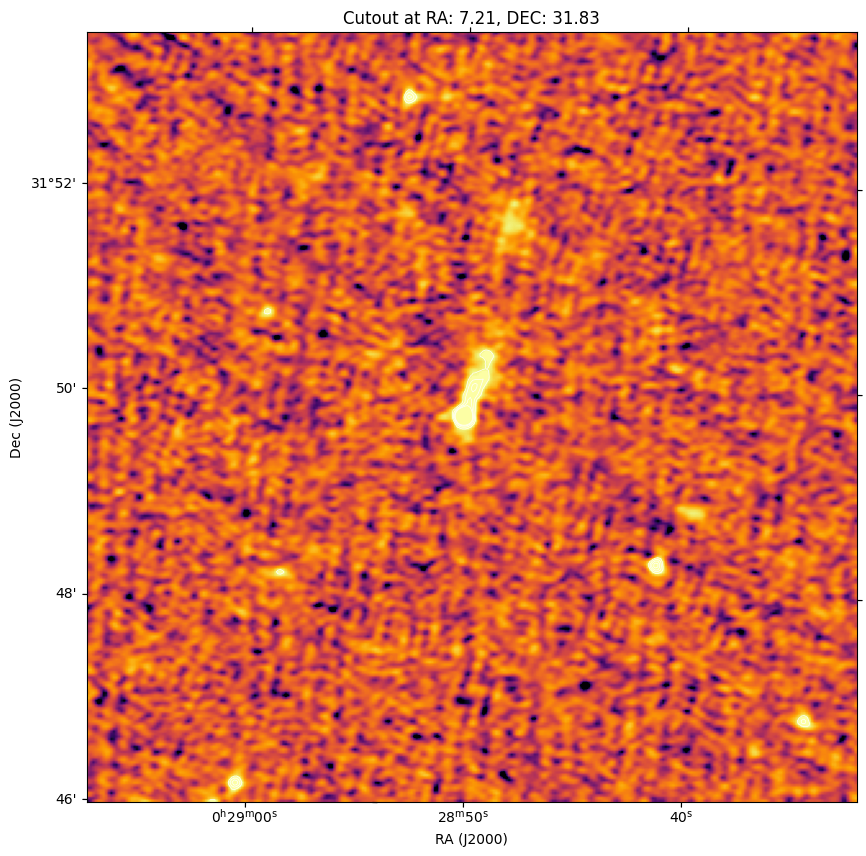

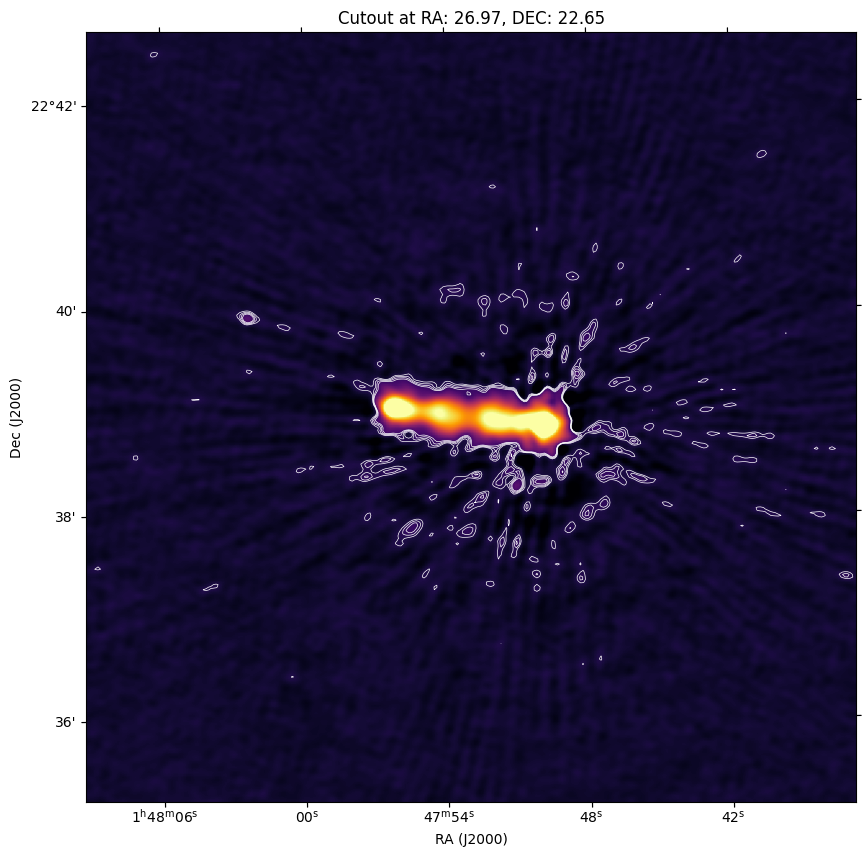

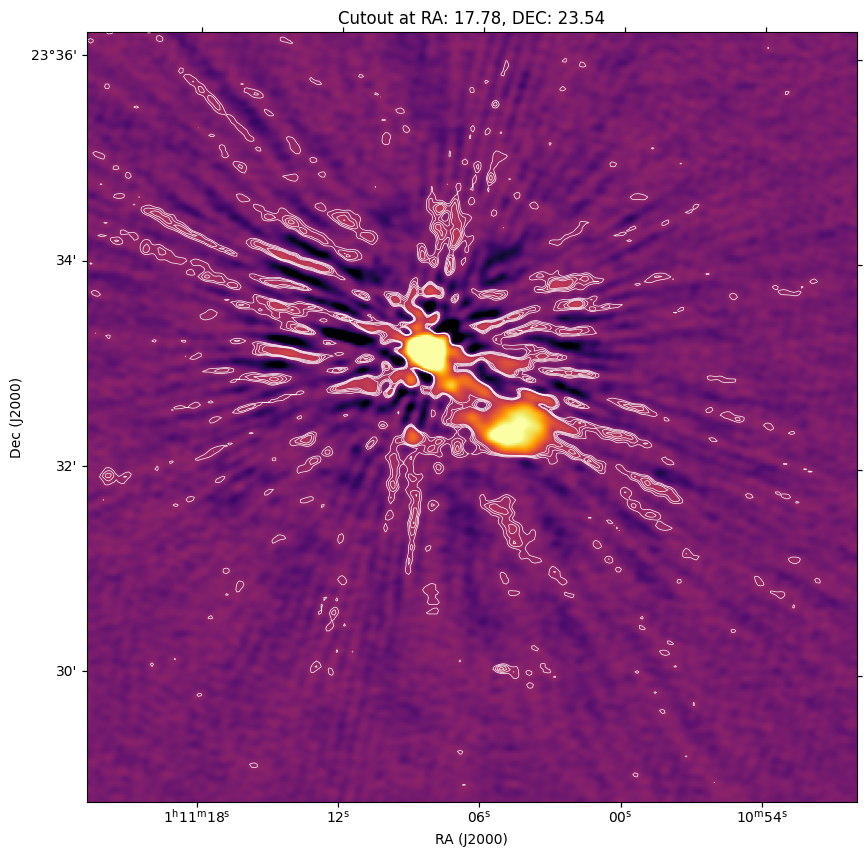

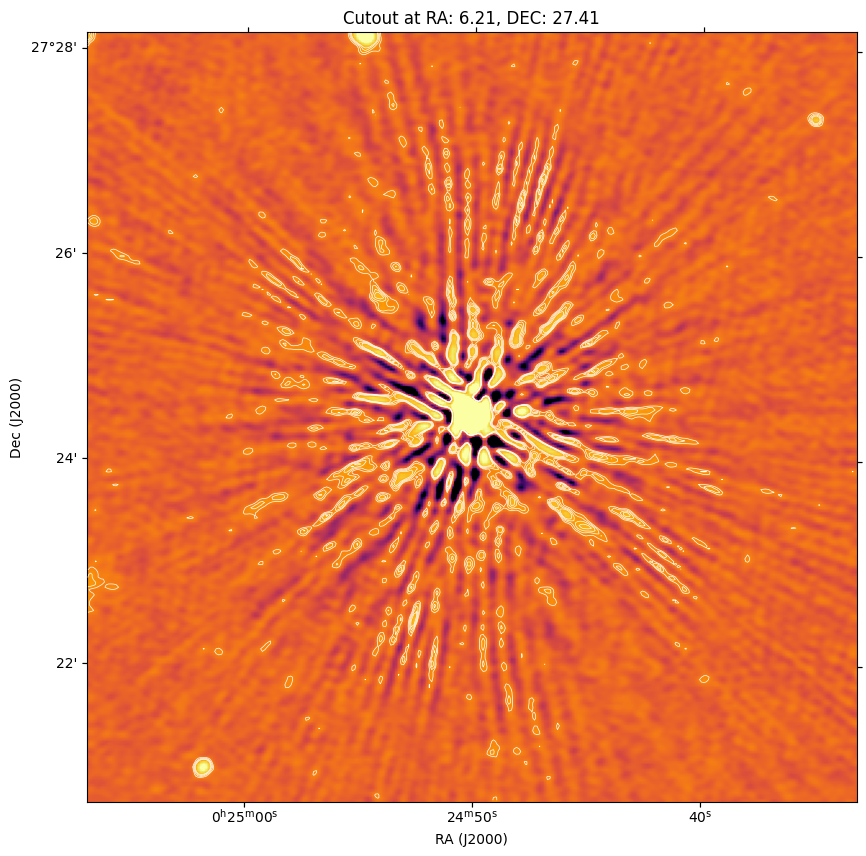

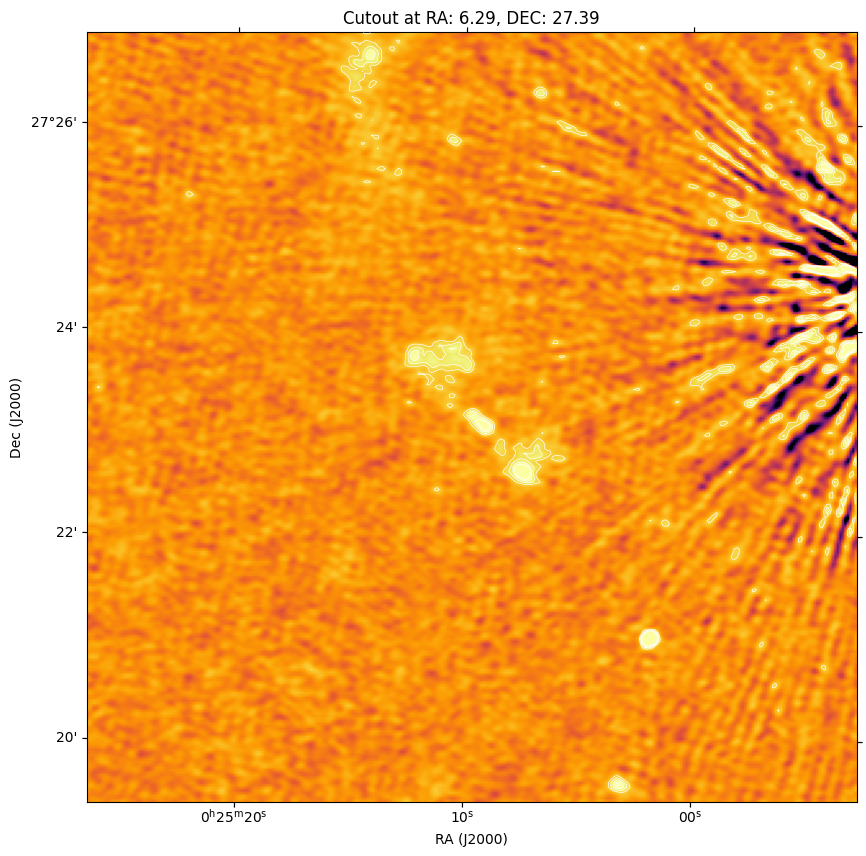

In [9]:
# Set the seed
np.random.seed(42)

# Get 5 random cutouts
random_cutouts = np.random.choice(cutouts, 5)
for cutout in random_cutouts:
    Vizualizer().vizualize_a_cutout(
        cutout=cutout,
        title=f"Cutout at RA: {cutout.ra:.2f}, DEC: {cutout.dec:.2f}",
        contour_levels=[4, 6, 8, 10]
    )

# We can get the pixel positions of the sources in the cutout using the CutoutCatalogue class:

We can constrain the component catalogue to include only sources that fall within the cutout area:

In [10]:
from strw_lofar_data_utils.core.cutout_maker import CutoutCatalogue

selected_cutout = random_cutouts[0]
cutout_catalogue = CutoutCatalogue(
    cutout=selected_cutout,
    catalogue=comp_cat,
    ra_col='RA',
    dec_col='DEC',
    comp_col='Component_Name',
    source_col='Parent_Source'
)

constrained_cat = cutout_catalogue.get_constrained_catalogue()
print(f"Number of sources in the constrained catalogue: {len(constrained_cat)}")
constrained_cat.head()

Number of sources in the constrained catalogue: 9


,Component_Name,RA,DEC,E_RA,E_DEC,Total_flux,E_Total_flux,Peak_flux,E_Peak_flux,S_Code,...,E_Min,E_PA,DC_Maj,DC_Min,DC_PA,ID_flag,Created,Deblended_from,Parent_Source,Field
63341,b'ILTJ002834.42+314648.8',7.143436,31.780233,0.461703,0.421232,1.235684,0.216480,0.649497,0.079239,b'S',...,0.847388,27.554868,6.949017,4.434091,53.342885,1,b'Ingest components',NaN,b'ILTJ002834.42+314648.8',b'Fall'
63574,b'ILTJ002839.56+314850.7',7.164836,31.814108,1.616451,0.975938,1.579612,0.404315,0.324034,0.069699,b'S',...,2.061521,26.436570,15.742356,8.517197,72.869950,5,b'Ingest components',NaN,b'ILTJ002839.56+314850.7',b'Fall'
63641,b'ILTJ002841.25+314819.2',7.171880,31.805352,0.200343,0.230260,1.659716,0.177831,1.133473,0.078908,b'S',...,0.469715,36.921641,4.601318,3.550916,9.794899,1,b'Ingest components',NaN,b'ILTJ002841.25+314819.2',b'Fall'
63911,b'ILTJ002847.99+315139.1',7.199973,31.860877,1.178270,2.210529,5.910892,0.914794,0.319577,0.046980,b'S',...,2.761333,17.419063,33.854944,18.417348,176.994620,3,b'Ingest components',NaN,b'ILTJ002849.34+315023.4',b'Fall'
63984,b'ILTJ002849.85+314954.4',7.207709,31.831798,0.856669,0.348576,15.433814,0.782709,3.832435,0.076512,b'M',...,0.291304,3.626141,29.420671,3.344205,159.472626,3,b'Ingest components',NaN,b'ILTJ002849.34+315023.4',b'Fall'


We can get a dictionay containg all the sources in the cutout as SourceBlobs (see documentation) which contain utilities to get the pixel positions of the sources in the cutout:

In [11]:
sb_dict = cutout_catalogue.get_source_blobs_from_catalogue()

for source_name, source_blob in sb_dict.items():
    in_cutout = source_blob.check_if_in_cutout(
        cutout_wcs=selected_cutout.get_wcs(),
        cutout_shape=selected_cutout.get_data().shape
    )
    coords = source_blob.get_coords()
    pixel_positions = source_blob.get_pixel_positions()
    for idx in range(len(coords)):
        print(f"Source: {source_name} | In Cutout: {in_cutout[idx]} | RA: {coords[idx].ra} | DEC: {coords[idx].dec} | Pixel X: {pixel_positions[idx][0]:.2f} | Pixel Y: {pixel_positions[idx][1]:.2f}")

Source: b'ILTJ002834.42+314648.8' | In Cutout: True | RA: 7.143435544611745 deg | DEC: 31.78023335306196 deg | Pixel X: 279.00 | Pixel Y: 31.00
Source: b'ILTJ002839.56+314850.7' | In Cutout: True | RA: 7.164836008860798 deg | DEC: 31.814107816077687 deg | Pixel X: 236.00 | Pixel Y: 112.00
Source: b'ILTJ002841.25+314819.2' | In Cutout: True | RA: 7.171879652956228 deg | DEC: 31.805352300986698 deg | Pixel X: 221.00 | Pixel Y: 91.00
Source: b'ILTJ002849.34+315023.4' | In Cutout: True | RA: 7.1999726074333825 deg | DEC: 31.860876505519364 deg | Pixel X: 165.00 | Pixel Y: 225.00
Source: b'ILTJ002849.34+315023.4' | In Cutout: True | RA: 7.207709152255077 deg | DEC: 31.83179818104993 deg | Pixel X: 149.00 | Pixel Y: 155.00
Source: b'ILTJ002852.73+315252.1' | In Cutout: True | RA: 7.219700494384715 deg | DEC: 31.88114096289292 deg | Pixel X: 125.00 | Pixel Y: 274.00
Source: b'ILTJ002858.49+314813.6' | In Cutout: True | RA: 7.24370022850774 deg | DEC: 31.80379626465209 deg | Pixel X: 75.00 | P

Finally we can visualize the cutouts with an overlay of the catalogue sources:

In [12]:
from strw_lofar_data_utils.core.cutout_maker.cutout_catalogue import CutoutCatalogue

def show_cutout_with_catalogue_overlay(
    cutout,
    comp_cat: pd.DataFrame,
    title: str,
    contour_levels: list = [4, 6, 8, 10],
    cmap='gray',
    rms=0.1,
) -> None:
    """
    Show a cutout with an overlay of catalog objects.
    """
    # Create a cutout catalogue object to handle the overlay
    cutout_cat = CutoutCatalogue(
        catalogue=comp_cat,
        cutout=cutout,
        ra_col='RA',
        dec_col='DEC',
        comp_col='Component_Name',
        source_col='Parent_Source',
    )
    
    Vizualizer().vizualize_a_cutout_with_catalogue_objects(
        cutout=cutout,
        cutout_cat=cutout_cat,
        title=title,
        contour_levels=contour_levels,
        cmap=cmap,
        rms=rms,
        legend=False
    )

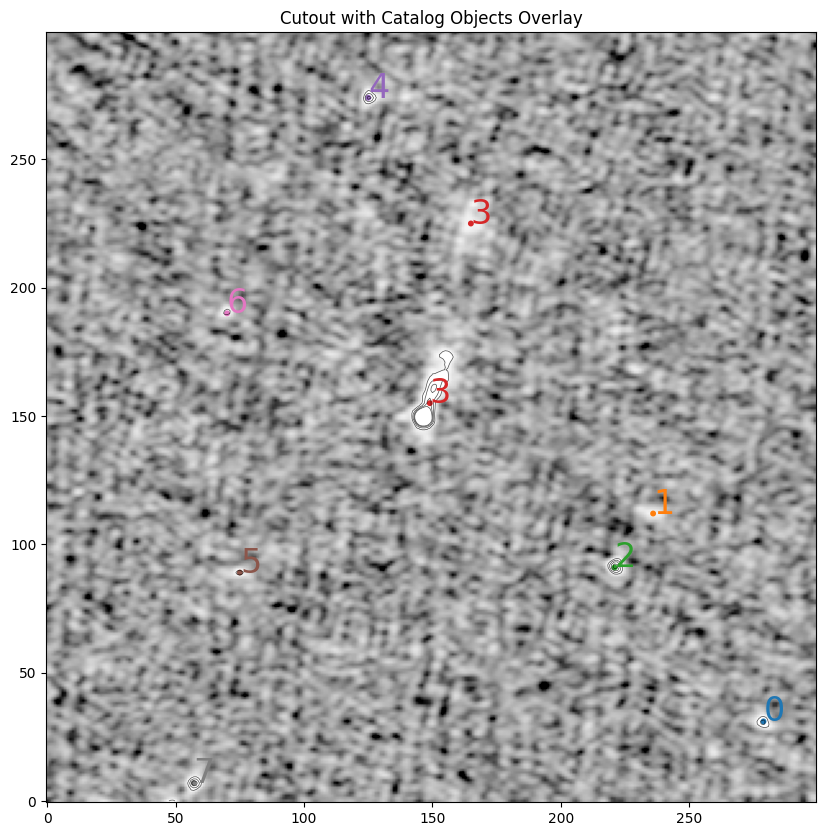

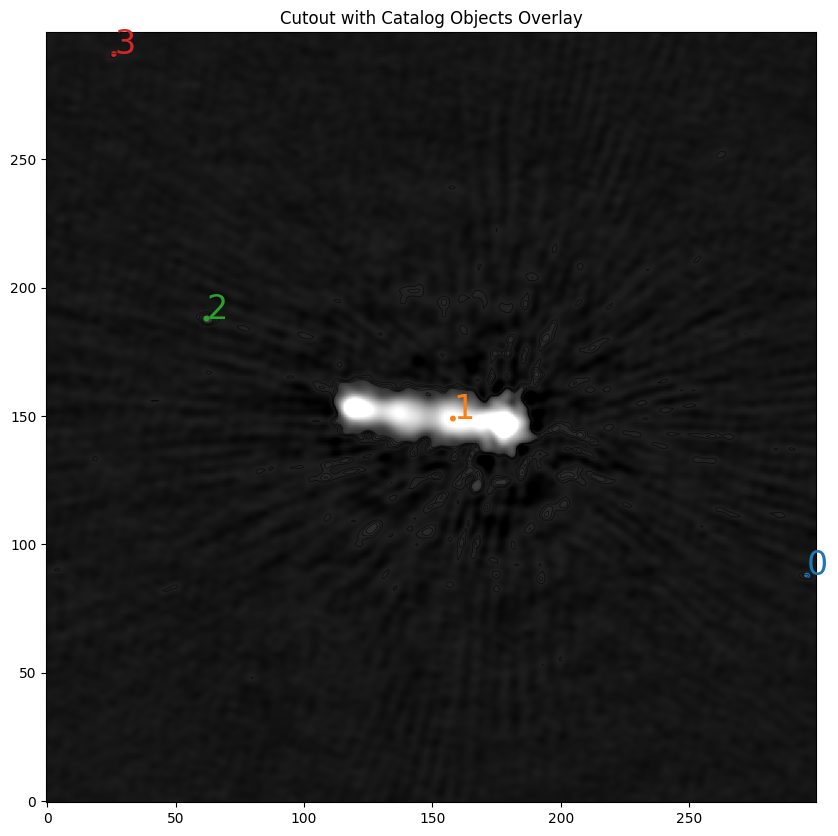

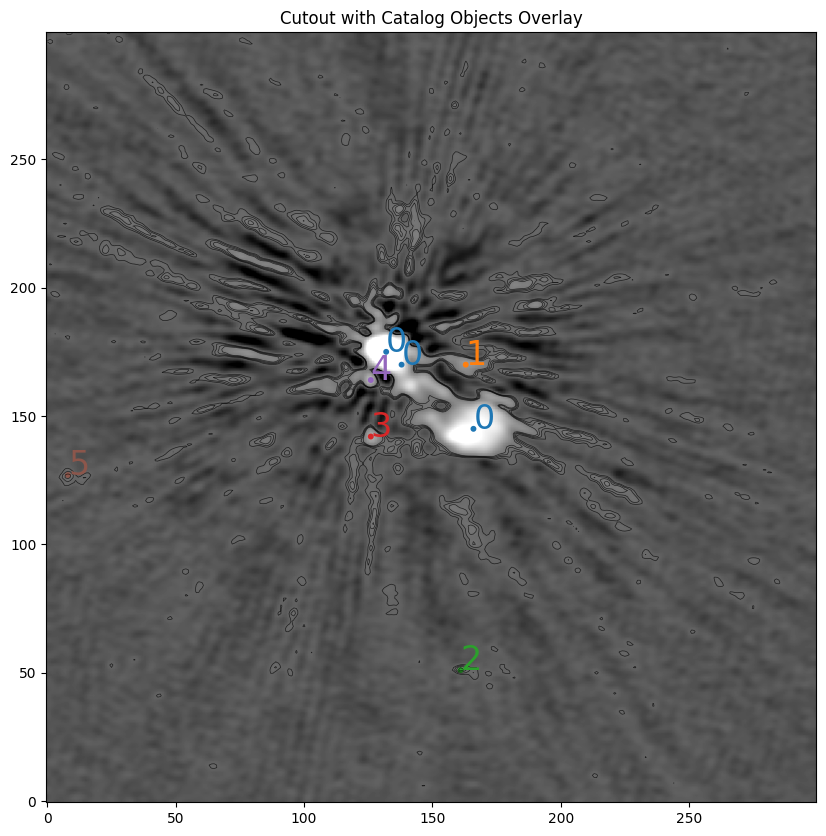

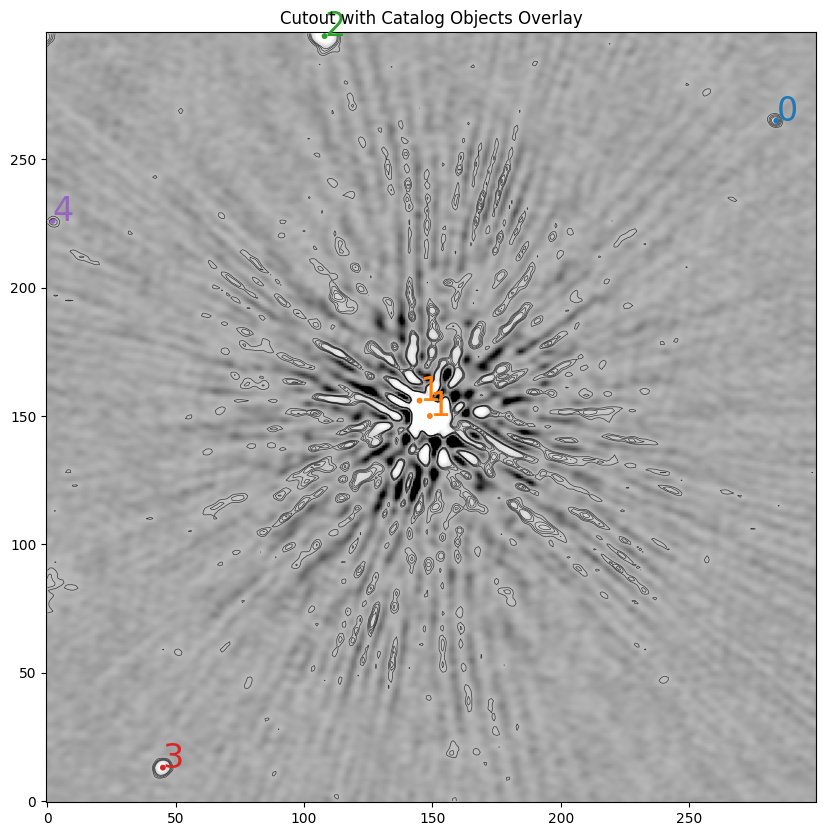

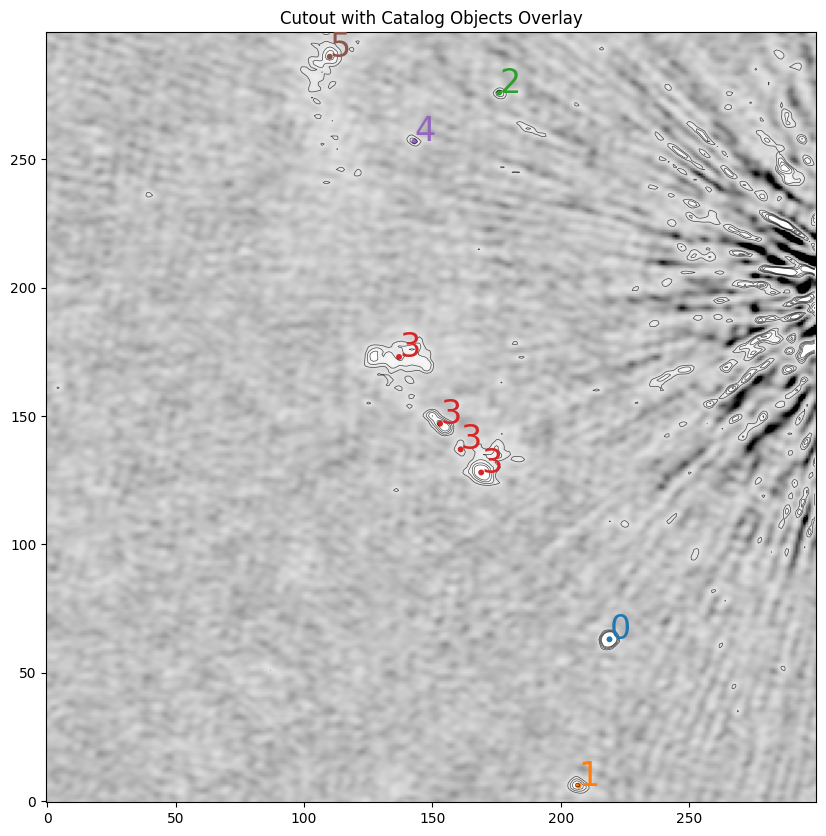

In [13]:
for cutout in random_cutouts:
    show_cutout_with_catalogue_overlay(
        cutout=cutout,
        comp_cat=comp_cat,
        title=f"Cutout at RA: {cutout.ra:.2f}, DEC: {cutout.dec:.2f} with Catalogue Overlay",
        contour_levels=[4, 6, 8, 10],
        cmap='gray',
        rms=0.1,
    )